## 1. Setup

Imports, helper functions, and raw data load. We work with polars as the primary DataFrame library and seaborn on top of matplotlib for plotting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Human": "#4C72B0", "Bot": "#DD8452"}

In [2]:
def summary_stats(arr):
    arr = np.asarray(arr)
    return {
        "n": len(arr),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "p25": float(np.percentile(arr, 25)),
        "median": float(np.median(arr)),
        "p75": float(np.percentile(arr, 75)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),
        "max": float(np.max(arr)),
    }


def describe_groups(human, bot):
    return pl.DataFrame(
        [
            {"group": "Human", **summary_stats(human)},
            {"group": "Bot", **summary_stats(bot)},
        ]
    )


def compare_distributions(human, bot, xlabel, title, log_x=False, clip_percentile=99.5):
    """Three-panel comparison:
        1. Normalized histogram with KDE overlay (shape of each distribution).
        2. Horizontal box plot on a log scale (quartiles, whiskers, outliers).
        3. Side-by-side bar chart of key statistics (mean / median / p75 / p95 / p99).
    A stats table is printed below.
    """
    human = np.asarray(human, dtype=float)
    bot = np.asarray(bot, dtype=float)

    all_values = np.concatenate([human, bot])
    all_groups = np.array(["Human"] * len(human) + ["Bot"] * len(bot))
    all_plot = np.log1p(all_values) if log_x else all_values
    prefix = "log1p " if log_x else ""
    can_log = bool((all_values > 0).all())

    fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

    hi = np.percentile(all_plot, clip_percentile)
    mask = all_plot <= hi
    sns.histplot(
        x=all_plot[mask],
        hue=all_groups[mask],
        hue_order=["Human", "Bot"],
        stat="density",
        common_norm=False,
        bins=50,
        kde=True,
        alpha=0.45,
        edgecolor=None,
        palette=PALETTE,
        ax=axes[0],
    )
    for g, arr in [("Human", human), ("Bot", bot)]:
        m = np.log1p(np.mean(arr)) if log_x else np.mean(arr)
        axes[0].axvline(m, color=PALETTE[g], linestyle="--", linewidth=1.2)
    axes[0].set_xlabel(prefix + xlabel)
    axes[0].set_title("Distribution shape (density + KDE, -- = mean)")

    sns.boxplot(
        x=all_values,
        y=all_groups,
        hue=all_groups,
        order=["Human", "Bot"],
        hue_order=["Human", "Bot"],
        palette=PALETTE,
        legend=False,
        fliersize=2,
        ax=axes[1],
    )
    if can_log:
        axes[1].set_xscale("log")
        axes[1].set_xlabel(f"{xlabel}  (log scale)")
    else:
        axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("")
    axes[1].set_title("Quartiles, whiskers, outliers")

    stat_names = ["mean", "median", "p75", "p95", "p99"]
    bar_stats, bar_values, bar_groups = [], [], []
    for arr, g in [(human, "Human"), (bot, "Bot")]:
        for name, v in [
            ("mean", np.mean(arr)),
            ("median", np.median(arr)),
            ("p75", np.percentile(arr, 75)),
            ("p95", np.percentile(arr, 95)),
            ("p99", np.percentile(arr, 99)),
        ]:
            bar_stats.append(name)
            bar_values.append(float(v))
            bar_groups.append(g)

    sns.barplot(
        x=bar_stats,
        y=bar_values,
        hue=bar_groups,
        order=stat_names,
        hue_order=["Human", "Bot"],
        palette=PALETTE,
        ax=axes[2],
    )
    if can_log:
        axes[2].set_yscale("log")
    for container in axes[2].containers:
        axes[2].bar_label(container, fmt="%.2g", fontsize=8, padding=2)
    axes[2].set_title("Key statistics side by side")
    axes[2].set_xlabel("")
    axes[2].set_ylabel(xlabel + (" (log)" if can_log else ""))
    axes[2].legend(title="", loc="upper left")

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

    print(describe_groups(human, bot))

In [3]:
DATA_DIR = Path.cwd().parent / "data/facebook-recruiting-iv-human-or-bot"

df_bids = pl.read_csv(DATA_DIR / "bids.csv")
df_train = pl.read_csv(DATA_DIR / "train.csv")
df_test = pl.read_csv(DATA_DIR / "test.csv")

In [4]:
df = df_bids.join(df_train, on="bidder_id", how="left")
df_labeled = df.filter(pl.col("outcome").is_not_null())

## 2. Data overview: class balance

Before we dive into behavior, we anchor on the class distribution and sanity-check the dataset shape.

### 2.1 Q1: Labeled bidders vs bids contributed, by class

Classification happens at the bidder level, so class balance there is what matters for loss weighting. But bots and humans can also differ hugely in *how many* bids they each produce, which affects downstream feature averages and sampling.

Labeled bidders           : 2,013
Humans / Bots             : 1,910 / 103
Bot rate (bidder-level)   : 5.12%


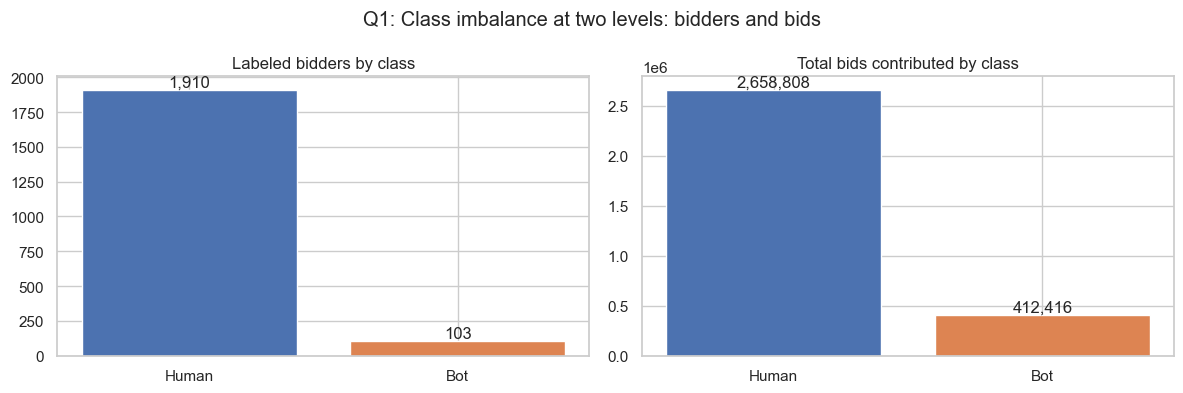

In [5]:
# Bidder-level class balance.
n_total = df_train.height
n_human = df_train.filter(pl.col("outcome") == 0).height
n_bot = df_train.filter(pl.col("outcome") == 1).height
bot_rate_bidder = n_bot / n_total
print(f"Labeled bidders           : {n_total:,}")
print(f"Humans / Bots             : {n_human:,} / {n_bot:,}")
print(f"Bot rate (bidder-level)   : {bot_rate_bidder:.2%}")

# Bid-level counts by class (how much data each class contributes).
bids_by_class = (
    df_labeled.group_by("outcome")
    .agg(pl.len().alias("n_bids"))
    .sort("outcome")
)
bid_counts = {int(row["outcome"]): int(row["n_bids"]) for row in bids_by_class.iter_rows(named=True)}
groups = ["Human", "Bot"]
colors = [PALETTE["Human"], PALETTE["Bot"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bidder_counts = [n_human, n_bot]
axes[0].bar(groups, bidder_counts, color=colors)
axes[0].set_title("Labeled bidders by class")
for i, v in enumerate(bidder_counts):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

bid_values = [bid_counts.get(0, 0), bid_counts.get(1, 0)]
axes[1].bar(groups, bid_values, color=colors)
axes[1].set_title("Total bids contributed by class")
for i, v in enumerate(bid_values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.suptitle("Q1: Class imbalance at two levels: bidders and bids")
plt.tight_layout()
plt.show()

**Observations**

- 2,013 labeled bidders total: 1,910 human / 103 bot, so **5.12% bot rate**.
- Severe class imbalance at the bidder level.
- Bids by class are more balanced (bots produce far more bids per bidder) because bots span more auctions and bid faster (explored later).
- Modeling implications:
  - Unweighted BCE will trivially reach ~95% accuracy by predicting all-human.
  - AUC-ROC is the right threshold-free metric. A single 80/20 split has only ~20 bots held out, so variance is high.
  - Plan repeated CV and track a lower percentile of AUC (e.g. 25th-percentile) across folds.

## 3. Q2: Understanding the `time` unit

The `time` column is obfuscated. Kaggle does not publish the unit. Our approach:

1. Inspect basic properties of the raw column (range, granularity, unit hypotheses).
2. Detect observation chunks by splitting on large gaps. Running autocorrelation across a gap would be meaningless.
3. Autocorrelate the bid-activity signal inside the largest chunk and take the first peak as 1 day. That gives a raw-units-per-second conversion.
4. Confirm by folding the timeline modulo the derived "day" and splitting humans vs bots. We expect humans to show day/night, bots to look flatter (bots don't sleep).

Once the unit is recovered we can build `hour_of_day`, `day_of_campaign`, and time-of-day-slot features for modeling.

### 3.1 Basic properties of the raw column

Range, granularity, and a quick unit-hypothesis check. The smallest positive gap between distinct timestamps is a strong hint at the underlying tick.

In [6]:
# Basic properties of the raw `time` column.
t = df_bids["time"].to_numpy()
t_min, t_max = int(t.min()), int(t.max())
span = t_max - t_min
unique_t = np.unique(t)
n_unique = len(unique_t)
granularity = int(np.diff(unique_t).min()) if n_unique > 1 else 0

print(f"total bids                           : {len(t):,}")
print(f"unique timestamps                    : {n_unique:,}")
print(f"min / max time                       : {t_min:,} / {t_max:,}")
print(f"span (max - min)                     : {span:,}")
print(f"smallest positive gap (granularity)  : {granularity:,}")

total bids                           : 7,656,334
unique timestamps                    : 776,529
min / max time                       : 9,631,916,842,105,263 / 9,772,885,210,526,315
span (max - min)                     : 140,968,368,421,052
smallest positive gap (granularity)  : 52,631,578


In [7]:
# Let's do a assumption check: if the smaleest gap is 1 second, then what?
total_secs = span / granularity
total_mins = total_secs / 60
total_hours = total_mins / 60
total_days = total_hours / 24
print(f"total time span in seconds            : {total_secs:,.0f} s")
print(f"total time span in minutes            : {total_mins:,.0f} min")
print(f"total time span in hours              : {total_hours:,.0f} hrs")
print(f"total time span in days               : {total_days:,.2f} days")

total time span in seconds            : 2,678,399 s
total time span in minutes            : 44,640 min
total time span in hours              : 744 hrs
total time span in days               : 31.00 days


**Observations**

- 7,656,334 bids; 776,529 distinct timestamps. Many bids share a time.
- Span (max - min) = 1.41e14 raw units.
- Smallest positive gap between distinct timestamps = **52,631,578** units.
- If the smallest gap represents **1 second**, span is approximately 31 days, which seems plausible for a campaign.

### 3.2 Detect observation chunks

The timeline isn't continuous. Splitting on large gaps separates the disjoint observation windows so later analyses (autocorrelation, folding) don't get polluted by the big inactive stretches.

Detected 3 observation chunk(s):
  chunk 1: [9,631,916,842,105,263 .. 9,645,558,894,736,842]  span=13,642,052,631,579  bids=2,872,017
  chunk 2: [9,695,580,000,000,000 .. 9,709,222,052,631,578]  span=13,642,052,631,578  bids=2,433,130
  chunk 3: [9,759,243,157,894,736 .. 9,772,885,210,526,315]  span=13,642,052,631,579  bids=2,351,187


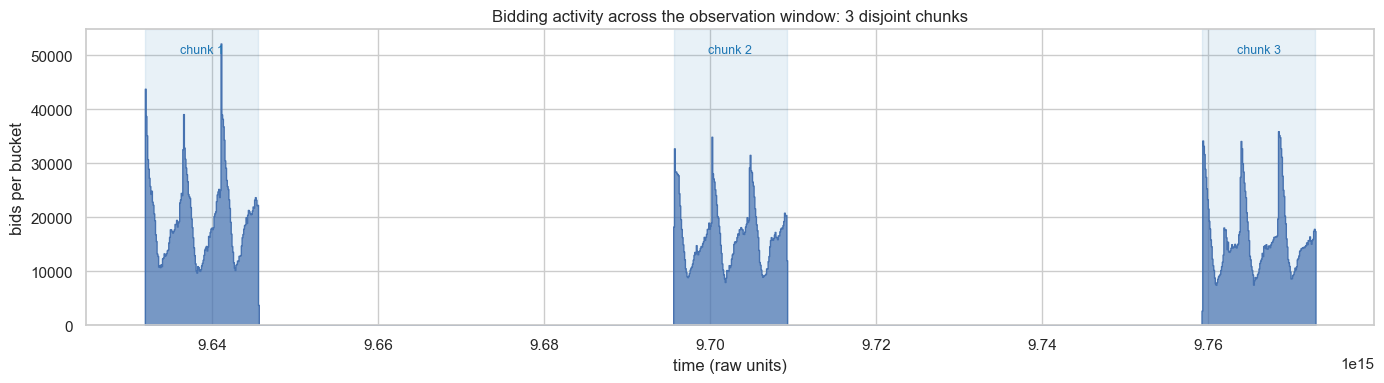

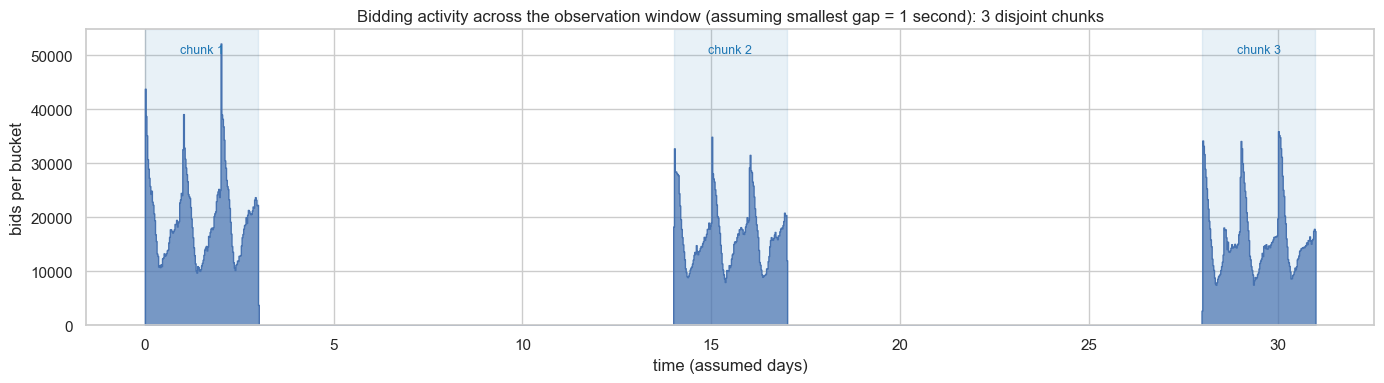

In [8]:
# Detect observation chunks by splitting on large gaps.
sorted_unique = np.sort(unique_t)
gaps = np.diff(sorted_unique)
# A "large" gap = any run of inactivity > 2% of the overall span.
big_gap_threshold = span * 0.02
break_positions = np.where(gaps > big_gap_threshold)[0]

chunks = []
start_val = sorted_unique[0]
for pos in break_positions:
    chunks.append((int(start_val), int(sorted_unique[pos])))
    start_val = sorted_unique[pos + 1]
chunks.append((int(start_val), int(sorted_unique[-1])))

print(f"Detected {len(chunks)} observation chunk(s):")
for i, (a, b) in enumerate(chunks, 1):
    n = int(((t >= a) & (t <= b)).sum())
    print(f"  chunk {i}: [{a:>20,} .. {b:>20,}]  span={b - a:>15,}  bids={n:,}")

# Visualize: bid activity with chunks shaded.
plt.figure(figsize=(14, 4))
sns.histplot(x=t, bins=1500, element="step", fill=True, alpha=0.7)
for i, (a, b) in enumerate(chunks):
    plt.axvspan(a, b, alpha=0.10, color="tab:blue")
    plt.text(
        (a + b) / 2,
        plt.ylim()[1] * 0.92,
        f"chunk {i + 1}",
        ha="center",
        fontsize=9,
        color="tab:blue",
    )
plt.xlabel("time (raw units)")
plt.ylabel("bids per bucket")
plt.title(
    f"Bidding activity across the observation window: {len(chunks)} disjoint chunks"
)
plt.tight_layout()
plt.show()

# Plot assuming the smallest gap represents 1 second, make x-axis in unit day
assumed_t = (t - t_min) / granularity  # Normalize to start at 0 and have gap=1.
assumed_t /= 60 * 60 * 24  # Convert seconds to days.

plt.figure(figsize=(14, 4))
sns.histplot(x=assumed_t, bins=1500, element="step", fill=True, alpha=0.7)
for i, (a, b) in enumerate(chunks):
    a_day = (a - t_min) / granularity / (60 * 60 * 24)
    b_day = (b - t_min) / granularity / (60 * 60 * 24)
    plt.axvspan(a_day, b_day, alpha=0.10, color="tab:blue")
    plt.text(
        (a_day + b_day) / 2,
        plt.ylim()[1] * 0.92,
        f"chunk {i + 1}",
        ha="center",
        fontsize=9,
        color="tab:blue",
    )
plt.xlabel("time (assumed days)")
plt.ylabel("bids per bucket")
plt.title(
    f"Bidding activity across the observation window (assuming smallest gap = 1 second): {len(chunks)} disjoint chunks"
)
plt.tight_layout()
plt.show()

### 3.3 Autocorrelation inside the largest chunk: find the daily period

Within a single chunk, autocorrelating the bid-activity signal reveals periodic structure. The first peak after lag 0 is our candidate for 1 day, which pins down the raw-unit-to-second conversion.

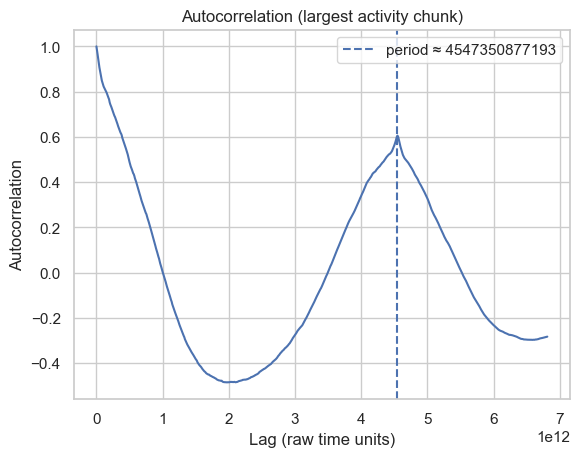

Candidate daily period	:4,547,350,877,193 raw units
=> 1 second	~52,631,375.89 raw units
=> 1 minute	~3,157,882,554 raw units
=> 1 hour	~189,472,953,216 raw units
Total calendar span	:31.00 days
  chunk 1 active duration	: 72.0 hours
  chunk 2 active duration	: 72.0 hours
  chunk 3 active duration	: 72.0 hours
  gap chunk 1 -> 2	: 11.00 days
  gap chunk 2 -> 3	: 11.00 days


In [9]:
# 1. Pick the largest chunk (most activity)
biggest_chunk = max(chunks, key=lambda ab: ((t >= ab[0]) & (t <= ab[1])).sum())
a, b = biggest_chunk

# 2. Keep timestamps only in this chunk
t_chunk = t[(t >= a) & (t <= b)]

# 3. Convert timestamps → counts over time bins
N_BINS = 1500
edges = np.linspace(a, b, N_BINS + 1)
counts, _ = np.histogram(t_chunk, bins=edges)

bucket_width = (b - a) / N_BINS

# 4. Compute autocorrelation
x = counts - counts.mean()
acf = np.correlate(x, x, mode="full")
acf = acf[len(acf) // 2 :]  # keep positive lags only
acf = acf / acf[0]  # normalize

lags = np.arange(len(acf)) * bucket_width


# 5. Find first peak (skip initial region)
def first_peak(y, skip=10):
    for i in range(skip, len(y) - 1):
        if y[i] > y[i - 1] and y[i] > y[i + 1] and y[i] > 0:
            return i
    return skip + np.argmax(y[skip:])


peak_idx = first_peak(acf)
period = lags[peak_idx]

# 6. Plot
plt.plot(lags[: len(lags) // 2], acf[: len(acf) // 2])
plt.axvline(period, linestyle="--", label=f"period ≈ {period:.0f}")
plt.xlabel("Lag (raw time units)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (largest activity chunk)")
plt.legend()
plt.show()

unit_per_sec = period / 86400
print(f"Candidate daily period\t:{period:,.0f} raw units")
print(f"=> 1 second\t~{unit_per_sec:,.2f} raw units")
print(f"=> 1 minute\t~{unit_per_sec * 60:,.0f} raw units")
print(f"=> 1 hour\t~{unit_per_sec * 3600:,.0f} raw units")
print(f"Total calendar span\t:{span / period:.2f} days")
for i, (ca, cb) in enumerate(chunks, 1):
    print(f"  chunk {i} active duration\t: {(cb - ca) / period * 24:.1f} hours")
for i in range(len(chunks) - 1):
    gap = chunks[i + 1][0] - chunks[i][1]
    print(f"  gap chunk {i + 1} -> {i + 2}\t: {gap / period:.2f} days")

**Observations**

- ACF first peak inside the largest chunk = 4.547e12 raw units. Taken as 1 day.
- Conversion: **1 second is approximately 52,631,376 raw units** (matches granularity, so granularity is about 1 second).
- Total calendar span = **31.00 days**.
- All 3 chunks have identical duration: **72.0 hours** (3 days) each.
- Both inter-chunk gaps = **11.00 days**.
- Active time = 9 of 31 days (~29%).

### 3.4 Per-chunk zoom: visual sanity check

Rescale each chunk's x-axis into hours (using the derived unit) and mark every 24 h. We expect 3 daily activity humps per chunk if the conversion is right.

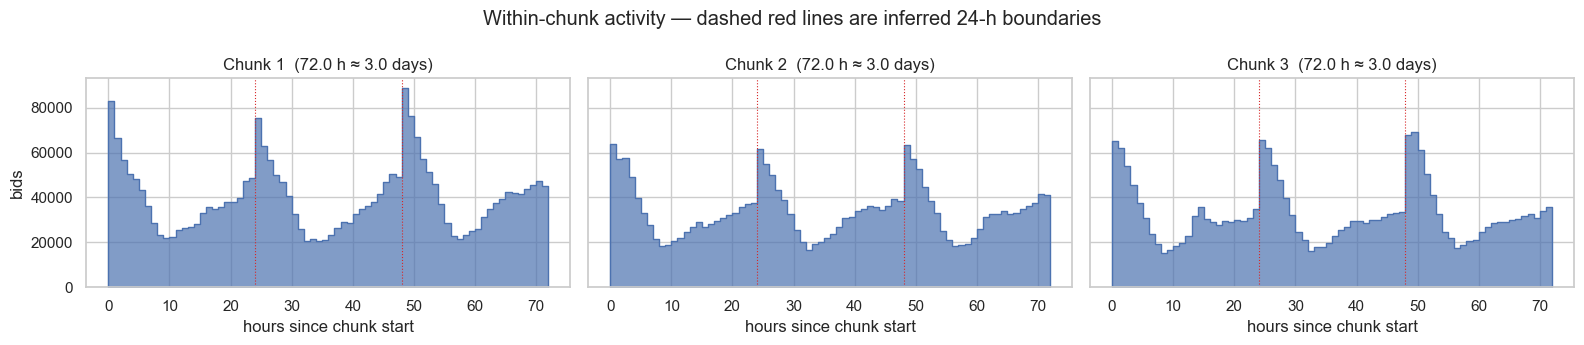

In [10]:
# Zoom into each chunk on a "hours since start" axis — each chunk should show
# ~3 daily activity spikes (humans sleep at night) and be ~3 days long.
fig, axes = plt.subplots(1, len(chunks), figsize=(16, 3.5), sharey=True)
if len(chunks) == 1:
    axes = [axes]
for ax, (ca, cb), i in zip(axes, chunks, range(1, len(chunks) + 1)):
    mask = (t >= ca) & (t <= cb)
    hours = (t[mask] - ca) / unit_per_sec / 3600
    sns.histplot(
        x=hours, bins=72, ax=ax, element="step", fill=True, alpha=0.7
    )
    duration_h = (cb - ca) / unit_per_sec / 3600
    for d in range(1, int(np.ceil(duration_h / 24))):
        ax.axvline(d * 24, color="tab:red", linestyle=":", linewidth=0.8)
    ax.set_title(f"Chunk {i}  ({duration_h:.1f} h ≈ {duration_h / 24:.1f} days)")
    ax.set_xlabel("hours since chunk start")
axes[0].set_ylabel("bids")
fig.suptitle("Within-chunk activity — dashed red lines are inferred 24-h boundaries")
fig.tight_layout()
plt.show()

**Observations**

- Each chunk shows exactly **3 humps** separated by 2 troughs, so 3 day/night cycles per chunk.
- Troughs align with the inferred 24-hour boundaries (dashed red lines).
- Independent visual confirmation of the daily period recovered via ACF.

### 3.5 Folded day/night pattern: humans vs bots

Final confirmation. Folding all bid times modulo the inferred day length should produce a clear day/night curve, and splitting by class should show humans sleeping while bots keep bidding.

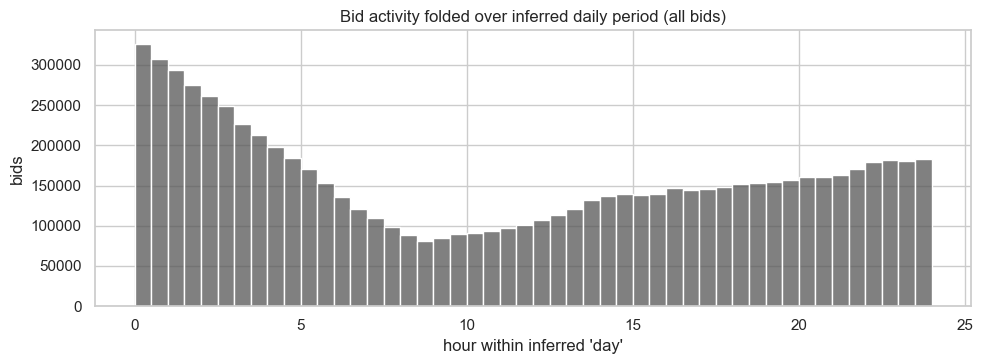

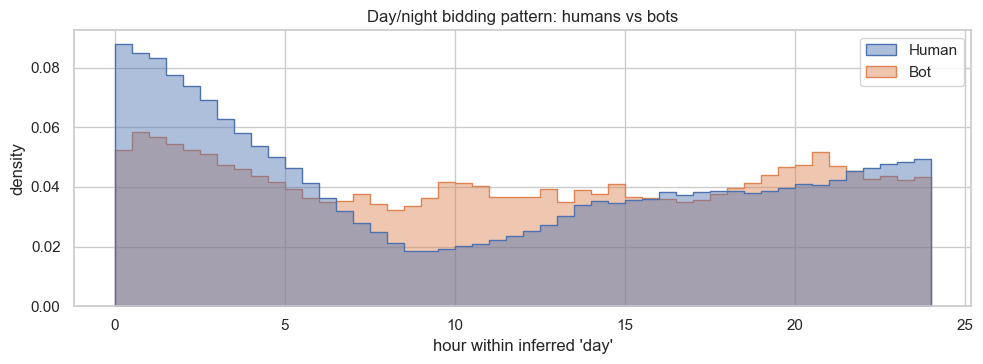

In [11]:
# Fold all bid times over the candidate daily period. A day/night curve
# (low activity at "night", high during "day") would confirm the unit.
phase_all = ((t - t_min) % period) / period * 24

plt.figure(figsize=(10, 3.8))
sns.histplot(x=phase_all, bins=48, color="#555555")
plt.xlabel("hour within inferred 'day'")
plt.ylabel("bids")
plt.title("Bid activity folded over inferred daily period (all bids)")
plt.tight_layout()
plt.show()

# Split by outcome: humans should sleep, bots shouldn't.
t_lab = df_labeled["time"].to_numpy()
out_lab = df_labeled["outcome"].to_numpy()
phase_lab = ((t_lab - t_min) % period) / period * 24
group_lab = np.where(out_lab == 1, "Bot", "Human")

plt.figure(figsize=(10, 3.8))
sns.histplot(
    x=phase_lab,
    hue=group_lab,
    hue_order=["Human", "Bot"],
    bins=48,
    stat="density",
    common_norm=False,
    alpha=0.45,
    element="step",
    palette=PALETTE,
)
plt.xlabel("hour within inferred 'day'")
plt.ylabel("density")
plt.title("Day/night bidding pattern: humans vs bots")
plt.tight_layout()
plt.show()

**Observations**

- Folded all-bids histogram has a clear daily shape with a trough in the "early hours" of the inferred day.
- Human curve dips sharply during the trough; bot curve is noticeably flatter.
- Bots keep bidding through the human nighttime, supporting the "bots don't sleep" hypothesis.
- Confirms (a) the unit conversion and (b) that `hour_of_day` carries class signal.

## 4. Activity volume per bidder

How much does each bidder bid, and how broadly?

### 4.1 Q3: Bids per auction, per bidder

How aggressively does a bidder participate in a single auction?

In [12]:
bids_per_auction = df_labeled.group_by(["bidder_id", "auction", "outcome"]).agg(
    pl.len().alias("n_bids")
)

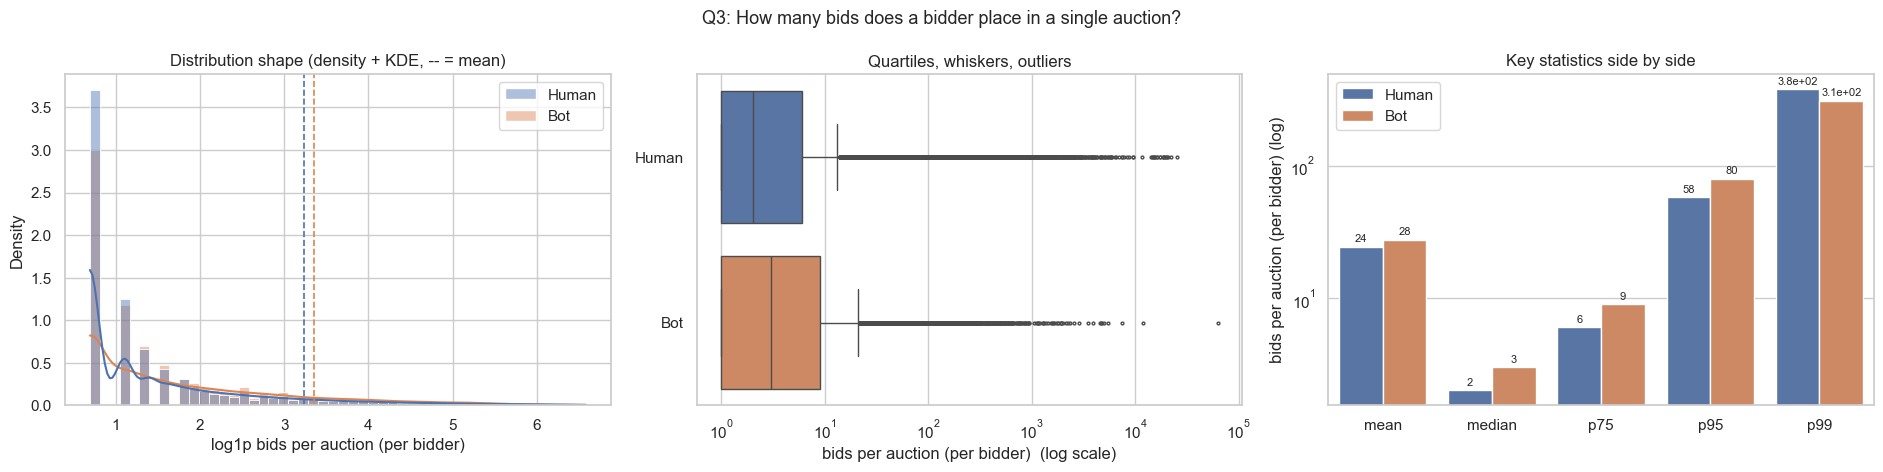

shape: (2, 11)
┌───────┬────────┬───────────┬────────────┬───┬─────┬──────┬────────┬─────────┐
│ group ┆ n      ┆ mean      ┆ std        ┆ … ┆ p75 ┆ p95  ┆ p99    ┆ max     │
│ ---   ┆ ---    ┆ ---       ┆ ---        ┆   ┆ --- ┆ ---  ┆ ---    ┆ ---     │
│ str   ┆ i64    ┆ f64       ┆ f64        ┆   ┆ f64 ┆ f64  ┆ f64    ┆ f64     │
╞═══════╪════════╪═══════════╪════════════╪═══╪═════╪══════╪════════╪═════════╡
│ Human ┆ 109231 ┆ 24.341149 ┆ 286.445217 ┆ … ┆ 6.0 ┆ 58.0 ┆ 378.7  ┆ 25532.0 │
│ Bot   ┆ 14939  ┆ 27.606667 ┆ 540.816259 ┆ … ┆ 9.0 ┆ 80.0 ┆ 311.62 ┆ 62485.0 │
└───────┴────────┴───────────┴────────────┴───┴─────┴──────┴────────┴─────────┘


In [13]:
human = bids_per_auction.filter(pl.col("outcome") == 0)["n_bids"].to_numpy()
bot = bids_per_auction.filter(pl.col("outcome") == 1)["n_bids"].to_numpy()

compare_distributions(
    human,
    bot,
    xlabel="bids per auction (per bidder)",
    title="Q3: How many bids does a bidder place in a single auction?",
    log_x=True,
)

**Observations**

- n: 109,231 human pairs vs 14,939 bot pairs.
- Means similar: human 24.3, bot 27.6 (both dominated by the tail).
- Bots skew heavier on every upper percentile:
  - p75: 9 (bot) vs 6 (human)
  - p95: 80 vs 58
  - max: 62,485 vs 25,532
- Signal is in the **tail**, not the typical bidder-auction pair.

### 4.2 Q4: Unique auctions per bidder

How broadly does each bidder participate?

In [14]:
auctions_per_bidder = (
    df_labeled.group_by("bidder_id")
    .agg(pl.n_unique("auction").alias("n_auctions"))
    .join(df_train, on="bidder_id", how="left")
)

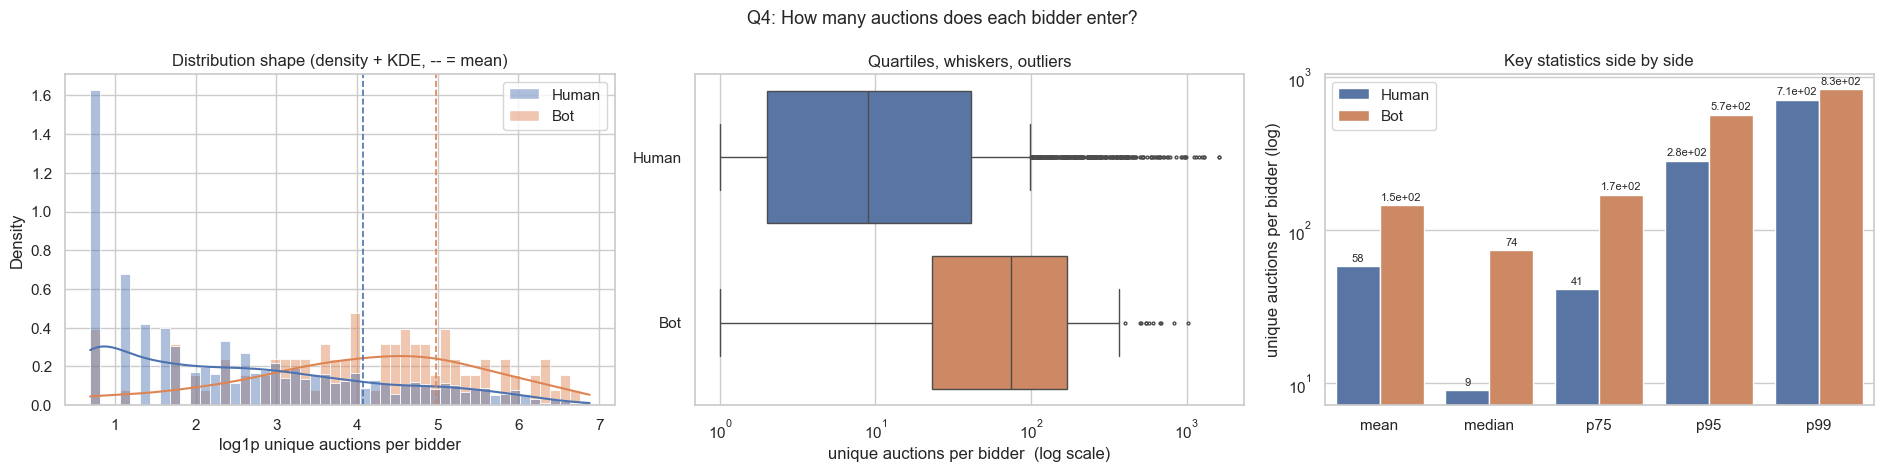

shape: (2, 11)
┌───────┬──────┬────────────┬────────────┬───┬───────┬───────┬───────┬────────┐
│ group ┆ n    ┆ mean       ┆ std        ┆ … ┆ p75   ┆ p95   ┆ p99   ┆ max    │
│ ---   ┆ ---  ┆ ---        ┆ ---        ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---    │
│ str   ┆ i64  ┆ f64        ┆ f64        ┆   ┆ f64   ┆ f64   ┆ f64   ┆ f64    │
╞═══════╪══════╪════════════╪════════════╪═══╪═══════╪═══════╪═══════╪════════╡
│ Human ┆ 1881 ┆ 58.070707  ┆ 142.895477 ┆ … ┆ 41.0  ┆ 283.0 ┆ 710.0 ┆ 1623.0 │
│ Bot   ┆ 103  ┆ 145.038835 ┆ 194.153774 ┆ … ┆ 170.5 ┆ 567.3 ┆ 828.0 ┆ 1018.0 │
└───────┴──────┴────────────┴────────────┴───┴───────┴───────┴───────┴────────┘


In [15]:
human = auctions_per_bidder.filter(pl.col("outcome") == 0)["n_auctions"].to_numpy()
bot = auctions_per_bidder.filter(pl.col("outcome") == 1)["n_auctions"].to_numpy()

compare_distributions(
    human,
    bot,
    xlabel="unique auctions per bidder",
    title="Q4: How many auctions does each bidder enter?",
    log_x=True,
)

**Observations**

- n: 1,881 human bidders vs 103 bot bidders.
- Bot mean = 145 auctions; human mean = 58 (about 2.5x).
- Gap widens in upper percentiles:
  - p75: 170.5 (bot) vs 41 (human), about 4x
  - p95: 567 vs 283, about 2x
- Typical human engages with dozens; typical bot scans hundreds.
- Strong candidate feature.

### 4.3 Q5: Maximum bids in a single auction (per bidder)

Peak bidding intensity: does the bidder ever hammer one auction?

In [16]:
max_bids = (
    bids_per_auction.group_by("bidder_id")
    .agg(pl.max("n_bids").alias("max_bids"))
    .join(df_train, on="bidder_id", how="left")
)

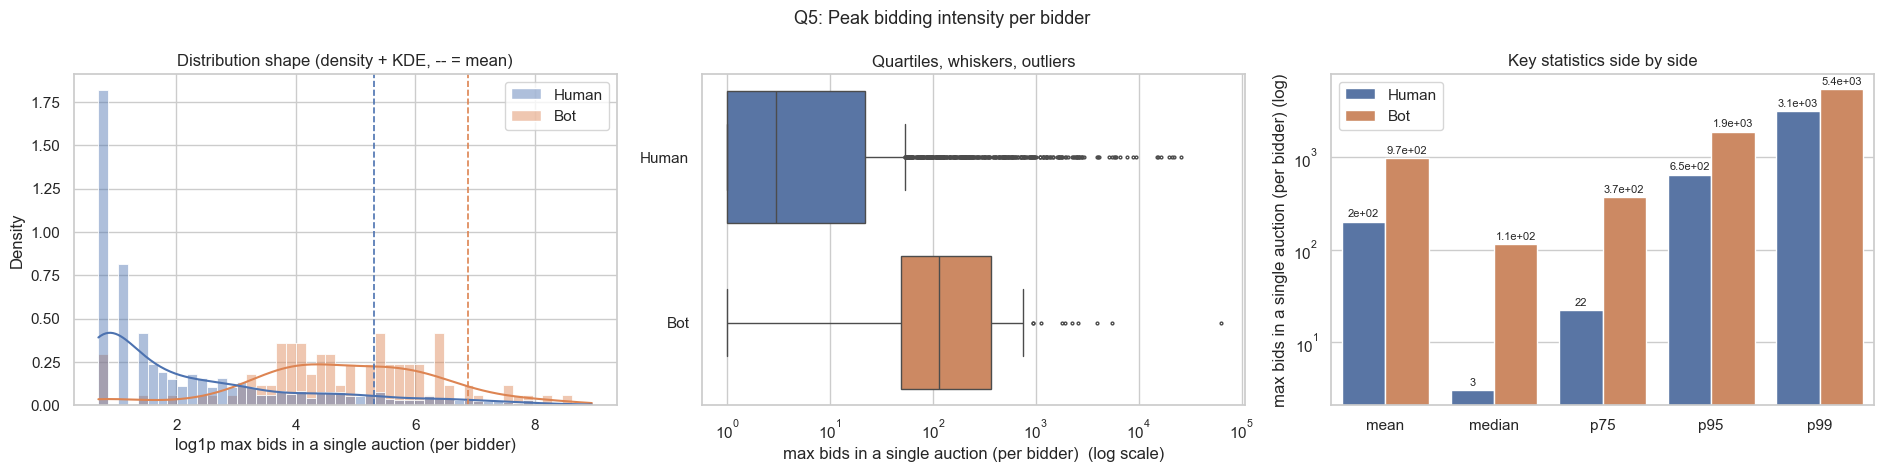

shape: (2, 11)
┌───────┬──────┬────────────┬─────────────┬───┬───────┬────────┬────────┬─────────┐
│ group ┆ n    ┆ mean       ┆ std         ┆ … ┆ p75   ┆ p95    ┆ p99    ┆ max     │
│ ---   ┆ ---  ┆ ---        ┆ ---         ┆   ┆ ---   ┆ ---    ┆ ---    ┆ ---     │
│ str   ┆ i64  ┆ f64        ┆ f64         ┆   ┆ f64   ┆ f64    ┆ f64    ┆ f64     │
╞═══════╪══════╪════════════╪═════════════╪═══╪═══════╪════════╪════════╪═════════╡
│ Human ┆ 1881 ┆ 201.267943 ┆ 1323.142717 ┆ … ┆ 22.0  ┆ 648.0  ┆ 3148.4 ┆ 25532.0 │
│ Bot   ┆ 103  ┆ 974.504854 ┆ 6137.543742 ┆ … ┆ 370.0 ┆ 1898.6 ┆ 5449.6 ┆ 62485.0 │
└───────┴──────┴────────────┴─────────────┴───┴───────┴────────┴────────┴─────────┘


In [17]:
human = max_bids.filter(pl.col("outcome") == 0)["max_bids"].to_numpy()
bot = max_bids.filter(pl.col("outcome") == 1)["max_bids"].to_numpy()

compare_distributions(
    human,
    bot,
    xlabel="max bids in a single auction (per bidder)",
    title="Q5: Peak bidding intensity per bidder",
    log_x=True,
)

**Observations**

- Bot mean = 974.5 bids; human mean = 201.3 (about 5x).
- Percentile gaps:
  - p75: 370 (bot) vs 22 (human), about 17x
  - p95: 1,898 vs 648, about 3x
  - max: 62,485 vs 25,532
- Bot p75 > human p95, so the bot median peak is already above human extremes.
- 62,485 bids in a single auction is operationally infeasible for a person.

### 4.4 Q6: Overall bidding rate (bids per unit time)

Sustained engagement, averaged over the bidder's full observed span.

In [18]:
bid_rate = (
    df_labeled.group_by("bidder_id")
    .agg(
        [pl.len().alias("n_bids"), (pl.max("time") - pl.min("time")).alias("time_span")]
    )
    .with_columns((pl.col("n_bids") / pl.col("time_span")).alias("bids_per_time"))
    .join(df_train, on="bidder_id", how="left")
)
clean_bid_rate = bid_rate.filter(
    (pl.col("bids_per_time").is_finite()) & (pl.col("bids_per_time") > 0)
)
human = clean_bid_rate.filter(pl.col("outcome") == 0)["bids_per_time"].to_numpy()
bot = clean_bid_rate.filter(pl.col("outcome") == 1)["bids_per_time"].to_numpy()

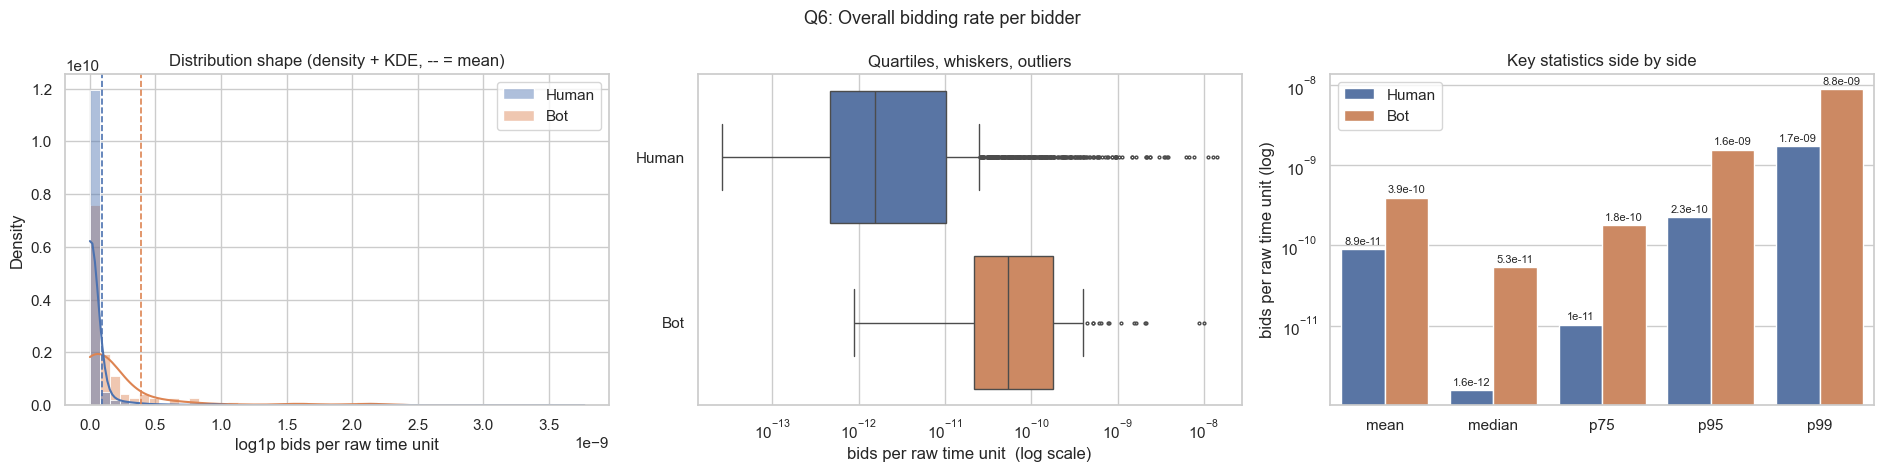

shape: (2, 11)
┌───────┬──────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ group ┆ n    ┆ mean       ┆ std        ┆ … ┆ p75        ┆ p95        ┆ p99       ┆ max       │
│ ---   ┆ ---  ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str   ┆ i64  ┆ f64        ┆ f64        ┆   ┆ f64        ┆ f64        ┆ f64       ┆ f64       │
╞═══════╪══════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ Human ┆ 1584 ┆ 8.9314e-11 ┆ 6.7800e-10 ┆ … ┆ 1.0263e-11 ┆ 2.2568e-10 ┆ 1.7133e-9 ┆ 1.4116e-8 │
│ Bot   ┆ 98   ┆ 3.9144e-10 ┆ 1.3683e-9  ┆ … ┆ 1.8003e-10 ┆ 1.5526e-9  ┆ 8.7982e-9 ┆ 1.0130e-8 │
└───────┴──────┴────────────┴────────────┴───┴────────────┴────────────┴───────────┴───────────┘


In [19]:
human_rate = clean_bid_rate.filter(pl.col("outcome") == 0)["bids_per_time"].to_numpy()
bot_rate = clean_bid_rate.filter(pl.col("outcome") == 1)["bids_per_time"].to_numpy()

compare_distributions(
    human_rate,
    bot_rate,
    xlabel="bids per raw time unit",
    title="Q6: Overall bidding rate per bidder",
    log_x=True,
)

**Observations** (bids per second, converted)

- Bot mean $\approx$ 0.0206 bids/s; human mean $\approx$ 0.0047 bids/s (about 4.4x).
- p95: bot $\approx$ 0.082 vs human $\approx$ 0.012, about 7x.
- Metric averages over the bidder's full span (including idle periods), so it captures **sustained engagement**, not peak speed.
- Sparse bidders with `time_span = 0` were filtered out (n: 1,584 humans / 98 bots retained).

## 5. Identity diversity

How many distinct IPs and devices does each bidder touch? Bots operating across proxy pools and emulated devices tend to look unusually diverse.

### 5.1 Q7: Unique IPs per bidder

How many distinct IPs does each bidder use? Bots routing through proxy pools should show many more.

In [20]:
ips = (
    df_labeled.group_by("bidder_id")
    .agg(pl.n_unique("ip").alias("n_ips"))
    .join(df_train, on="bidder_id", how="left")
)

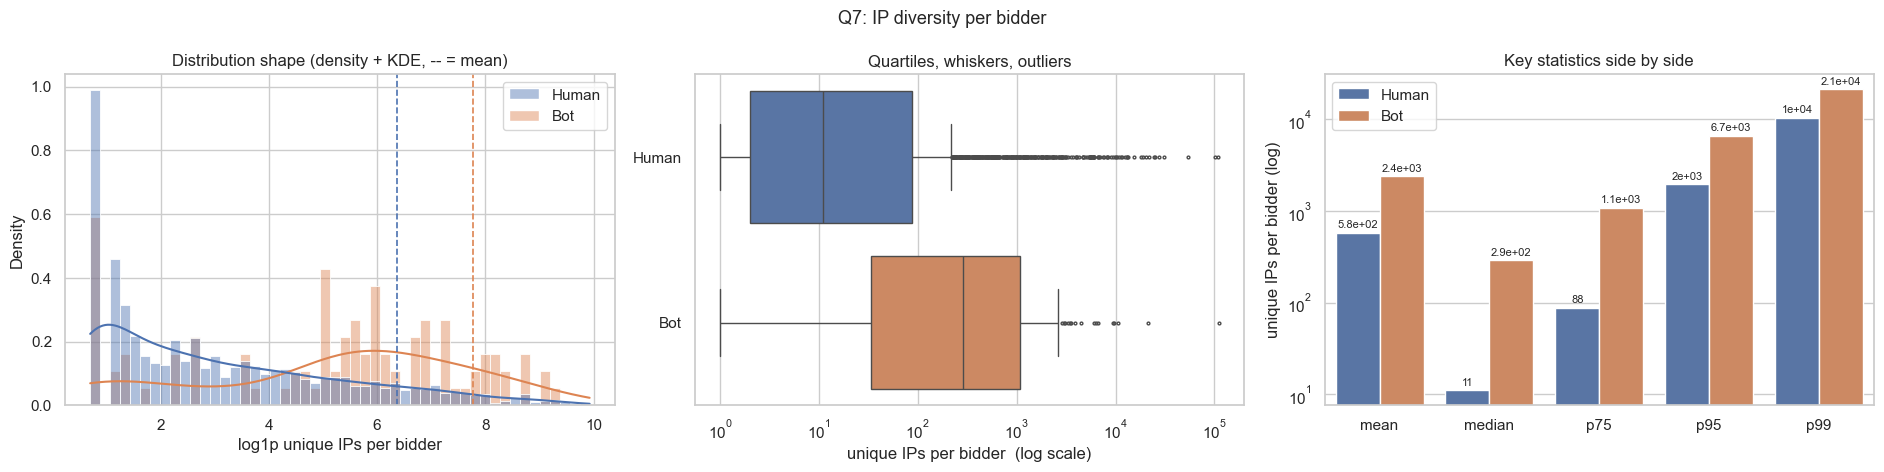

shape: (2, 11)
┌───────┬──────┬─────────────┬──────────────┬───┬────────┬────────┬──────────┬──────────┐
│ group ┆ n    ┆ mean        ┆ std          ┆ … ┆ p75    ┆ p95    ┆ p99      ┆ max      │
│ ---   ┆ ---  ┆ ---         ┆ ---          ┆   ┆ ---    ┆ ---    ┆ ---      ┆ ---      │
│ str   ┆ i64  ┆ f64         ┆ f64          ┆   ┆ f64    ┆ f64    ┆ f64      ┆ f64      │
╞═══════╪══════╪═════════════╪══════════════╪═══╪════════╪════════╪══════════╪══════════╡
│ Human ┆ 1881 ┆ 581.256247  ┆ 4139.577375  ┆ … ┆ 88.0   ┆ 1960.0 ┆ 10413.2  ┆ 109159.0 │
│ Bot   ┆ 103  ┆ 2387.796117 ┆ 11214.833549 ┆ … ┆ 1089.0 ┆ 6656.5 ┆ 21281.32 ┆ 111918.0 │
└───────┴──────┴─────────────┴──────────────┴───┴────────┴────────┴──────────┴──────────┘


In [21]:
human = ips.filter(pl.col("outcome") == 0)["n_ips"].to_numpy()
bot = ips.filter(pl.col("outcome") == 1)["n_ips"].to_numpy()

compare_distributions(
    human,
    bot,
    xlabel="unique IPs per bidder",
    title="Q7: IP diversity per bidder",
    log_x=True,
)

**Observations**

- Bot mean = 2,388 IPs; human mean = 581 (about 4x).
- p75 gap is extreme: 1,089 (bot) vs 88 (human), about 12x.
- p95: 6,656 vs 1,960, about 3x.
- Suggests bots route through proxy pools or distributed infrastructure.
- The **ratio** `unique_ips / total_bids` should carry more signal than the raw count. A bot with many bids is expected to touch many IPs, so the ratio is what's anomalous.

### 5.2 Q8: Unique devices per bidder

Same diversity idea as IPs but at the device level. A human typically cycles between a phone and a laptop; a bot fleet can pose as dozens or hundreds of devices.

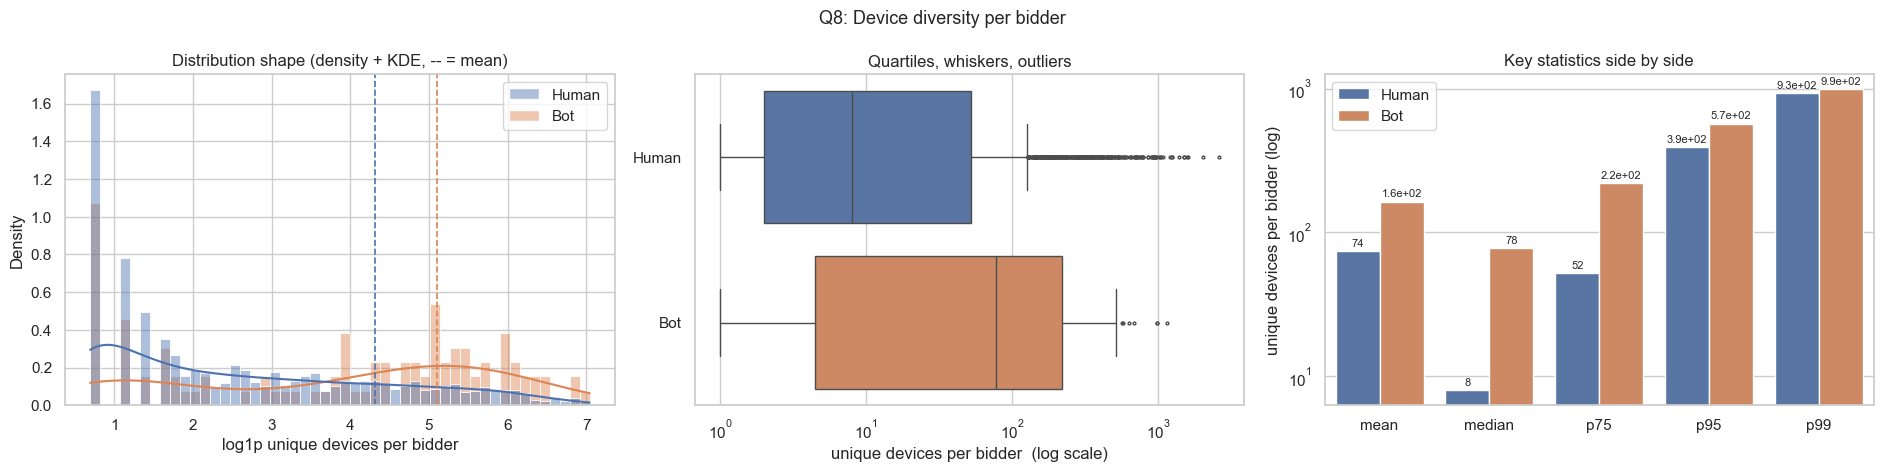

shape: (2, 11)
┌───────┬──────┬───────────┬────────────┬───┬───────┬───────┬────────┬────────┐
│ group ┆ n    ┆ mean      ┆ std        ┆ … ┆ p75   ┆ p95   ┆ p99    ┆ max    │
│ ---   ┆ ---  ┆ ---       ┆ ---        ┆   ┆ ---   ┆ ---   ┆ ---    ┆ ---    │
│ str   ┆ i64  ┆ f64       ┆ f64        ┆   ┆ f64   ┆ f64   ┆ f64    ┆ f64    │
╞═══════╪══════╪═══════════╪════════════╪═══╪═══════╪═══════╪════════╪════════╡
│ Human ┆ 1881 ┆ 73.947368 ┆ 184.511842 ┆ … ┆ 52.0  ┆ 392.0 ┆ 931.0  ┆ 2618.0 │
│ Bot   ┆ 103  ┆ 163.61165 ┆ 221.727605 ┆ … ┆ 219.0 ┆ 569.4 ┆ 985.76 ┆ 1144.0 │
└───────┴──────┴───────────┴────────────┴───┴───────┴───────┴────────┴────────┘


In [22]:
devices = (
    df_labeled.group_by("bidder_id")
    .agg(pl.n_unique("device").alias("n_devices"))
    .join(df_train, on="bidder_id", how="left")
)

human = devices.filter(pl.col("outcome") == 0)["n_devices"].to_numpy()
bot = devices.filter(pl.col("outcome") == 1)["n_devices"].to_numpy()

compare_distributions(
    human,
    bot,
    xlabel="unique devices per bidder",
    title="Q8: Device diversity per bidder",
    log_x=True,
)

**Observations**

- Bot mean = 163.6 devices; human mean = 74.0 (about 2.2x).
- Percentile gaps:
  - median: bot 78 vs human 8 (about 10x)
  - p75: bot 219 vs human 52 (about 4.2x)
  - p95: bot 569 vs human 392
- Bot **median** (78) is already higher than the human **p75** (52), so even a typical bot looks extreme by human standards.
- Same story as IPs: the ratio `unique_devices / total_bids` will likely be more discriminative than the absolute count.

## 6. Timing behavior

How fast, how regular, and when does each bidder act?

### 6.1 Q9: Time between consecutive own bids

Reaction speed and regularity when a bidder responds to their own previous bid.

In [23]:
time_diffs = (
    df_labeled.sort(["bidder_id", "auction", "time"])
    .with_columns(pl.col("time").diff().over(["bidder_id", "auction"]).alias("dt"))
    .filter(pl.col("dt").is_not_null())
)

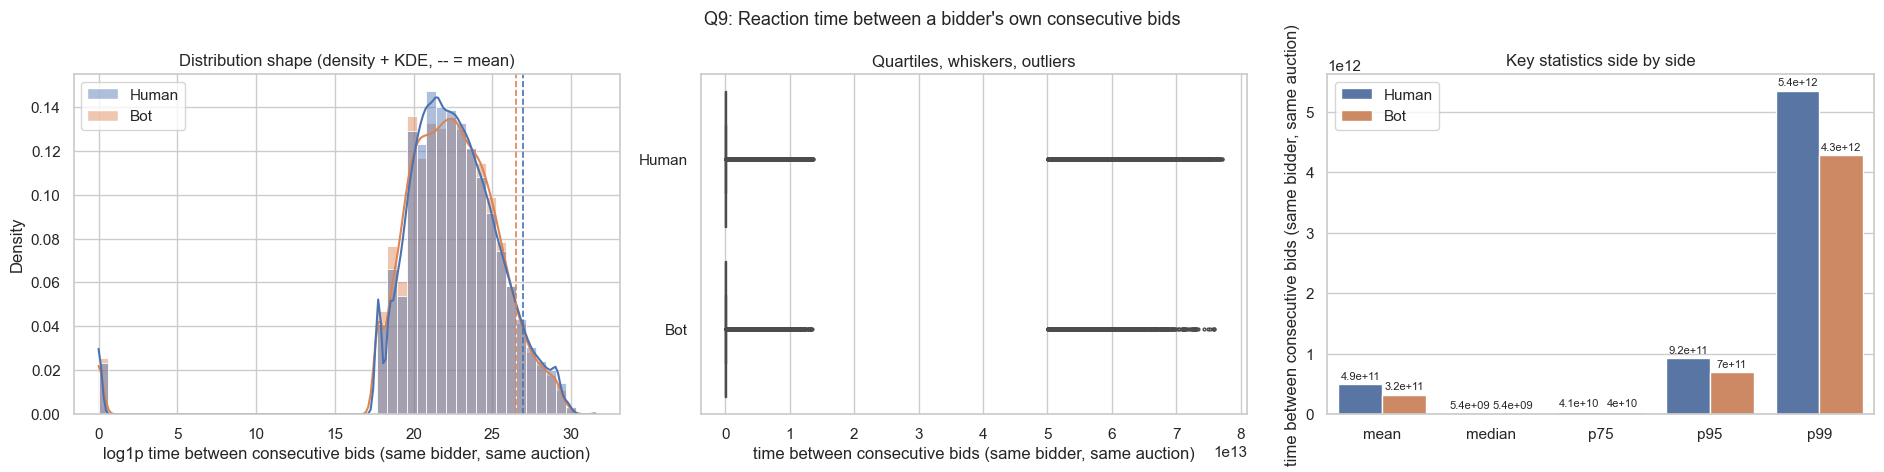

shape: (2, 11)
┌───────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ group ┆ n       ┆ mean      ┆ std       ┆ … ┆ p75       ┆ p95       ┆ p99       ┆ max       │
│ ---   ┆ ---     ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str   ┆ i64     ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Human ┆ 2549577 ┆ 4.9177e11 ┆ 4.3048e12 ┆ … ┆ 4.0579e10 ┆ 9.2405e11 ┆ 5.3517e12 ┆ 7.7156e13 │
│ Bot   ┆ 397477  ┆ 3.2053e11 ┆ 3.1530e12 ┆ … ┆ 4.0053e10 ┆ 6.9543e11 ┆ 4.2874e12 ┆ 7.5935e13 │
└───────┴─────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [24]:
human_dt = time_diffs.filter(pl.col("outcome") == 0)["dt"].to_numpy()
bot_dt = time_diffs.filter(pl.col("outcome") == 1)["dt"].to_numpy()

compare_distributions(
    human_dt,
    bot_dt,
    xlabel="time between consecutive bids (same bidder, same auction)",
    title="Q9: Reaction time between a bidder's own consecutive bids",
    log_x=True,
)

**Observations** (converted with 1 second $\approx$ 52.6M raw units)

- p75 nearly identical: human ~770 s, bot ~760 s.
- Bot < human on every upper percentile:
  - mean: bot 1.7 h vs human 2.6 h
  - p95: bot 3.7 h vs human 4.9 h
  - p99: bot 22.6 h vs human 28.3 h
- Bots slightly faster between **own** consecutive bids, but separation is mild.
- Reaction to rivals (next subsection) is the sharper angle on the same question.

### 6.2 Q10: Reaction time to *other* bidders in the same auction

The previous subsection measured self-cadence. But bidding is a competitive process, so the more informative signal is how fast a bidder responds when a *different* bidder acts. For each bid, we compute the time since the previous bid **by someone else** in the same auction.

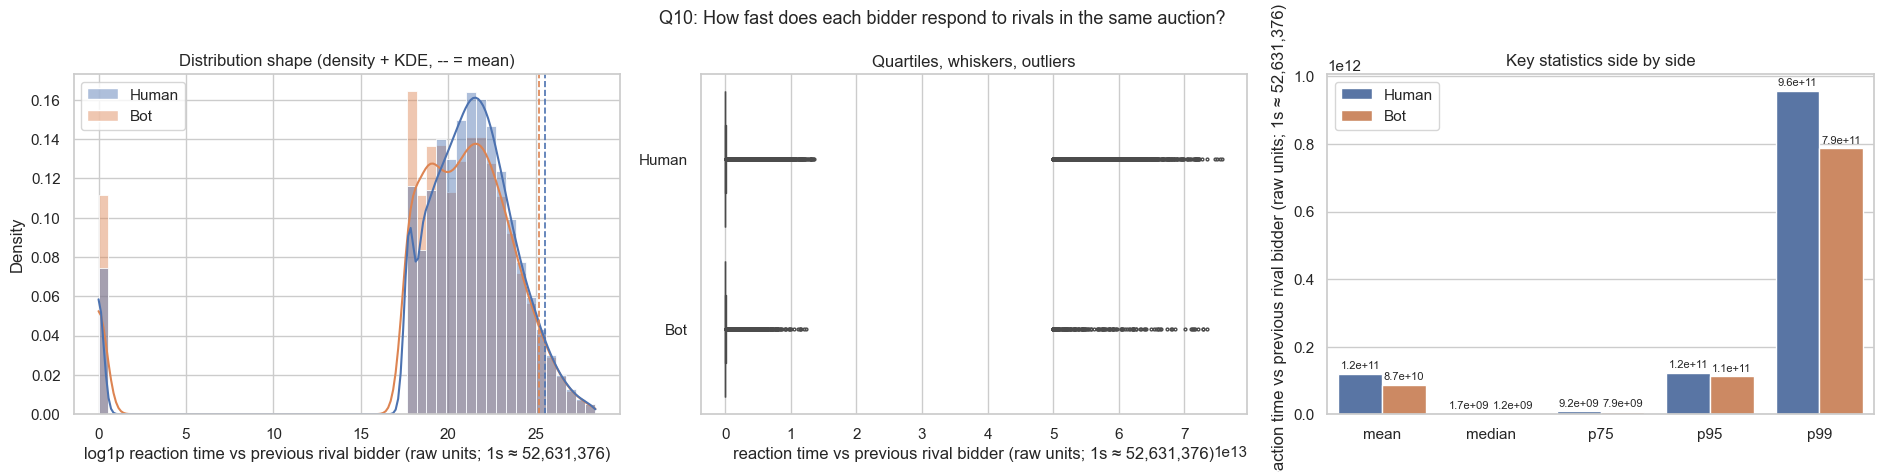

shape: (2, 11)
┌───────┬─────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ group ┆ n       ┆ mean      ┆ std       ┆ … ┆ p75      ┆ p95       ┆ p99       ┆ max       │
│ ---   ┆ ---     ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---       ┆ ---       ┆ ---       │
│ str   ┆ i64     ┆ f64       ┆ f64       ┆   ┆ f64      ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪═════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ Human ┆ 1348783 ┆ 1.2015e11 ┆ 2.0861e12 ┆ … ┆ 9.1579e9 ┆ 1.2274e11 ┆ 9.5809e11 ┆ 7.5819e13 │
│ Bot   ┆ 224178  ┆ 8.7079e10 ┆ 1.6831e12 ┆ … ┆ 7.8947e9 ┆ 1.1189e11 ┆ 7.8667e11 ┆ 7.3464e13 │
└───────┴─────────┴───────────┴───────────┴───┴──────────┴───────────┴───────────┴───────────┘


In [25]:
# For each bid, compute the time since the last bid by a DIFFERENT bidder
# in the same auction. Keep only "reaction" events (previous bid was someone else).
reacts = (
    df_labeled.sort(["auction", "time"])
    .with_columns(
        (pl.col("time") - pl.col("time").shift(1).over("auction")).alias("dt_any"),
        (pl.col("bidder_id") != pl.col("bidder_id").shift(1).over("auction")).alias(
            "is_react"
        ),
    )
    .filter(pl.col("is_react") & pl.col("dt_any").is_not_null())
)

human_r = reacts.filter(pl.col("outcome") == 0)["dt_any"].to_numpy()
bot_r = reacts.filter(pl.col("outcome") == 1)["dt_any"].to_numpy()

compare_distributions(
    human_r,
    bot_r,
    xlabel=f"reaction time vs previous rival bidder (raw units; 1s ≈ {unit_per_sec:,.0f})",
    title="Q10: How fast does each bidder respond to rivals in the same auction?",
    log_x=True,
)

**Observations** (converted to seconds)

- Bots react faster to a rival on every percentile:
  - p75: bot 150 s vs human 174 s
  - p95: bot ~35 min vs human ~39 min
  - p99: bot ~4.1 h vs human ~5.1 h
- Per-bid gap is modest but systematic.
- Aggregated per bidder (`dt_others_median`, `dt_others_min`) should separate classes more sharply than the self-reaction metric.
- Interpretation: bots specifically respond when challenged, not just maintain their own cadence.

### 6.3 Q11: Timing regularity (std of gaps between bids)

Are bots more rhythmic than humans?

In [26]:
dt_std = (
    time_diffs.group_by("bidder_id")
    .agg(pl.std("dt").alias("dt_std"))
    .join(df_train, on="bidder_id", how="left")
)

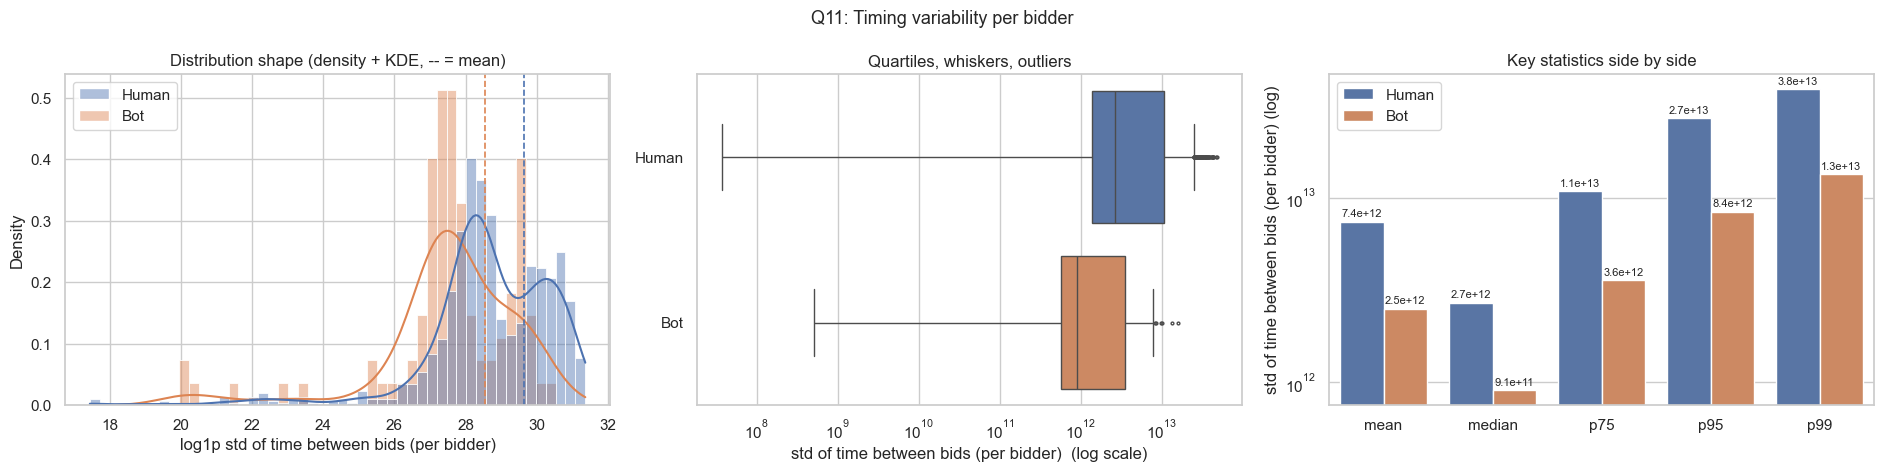

shape: (2, 11)
┌───────┬──────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ group ┆ n    ┆ mean      ┆ std       ┆ … ┆ p75       ┆ p95       ┆ p99       ┆ max       │
│ ---   ┆ ---  ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str   ┆ i64  ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪══════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Human ┆ 1131 ┆ 7.4108e12 ┆ 9.1377e12 ┆ … ┆ 1.0824e13 ┆ 2.6897e13 ┆ 3.8407e13 ┆ 4.8758e13 │
│ Bot   ┆ 98   ┆ 2.5024e12 ┆ 3.1936e12 ┆ … ┆ 3.5682e12 ┆ 8.3888e12 ┆ 1.3396e13 ┆ 1.6048e13 │
└───────┴──────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [27]:
human_std = dt_std.filter(pl.col("outcome") == 0)["dt_std"].drop_nulls().to_numpy()
bot_std = dt_std.filter(pl.col("outcome") == 1)["dt_std"].drop_nulls().to_numpy()

compare_distributions(
    human_std,
    bot_std,
    xlabel="std of time between bids (per bidder)",
    title="Q11: Timing variability per bidder",
    log_x=True,
)

**Observations**

- Bot `dt_std` **lower** than human, so bots are more regular:
  - mean: bot 2.50e12 vs human 7.41e12 (about 3x)
  - p75: bot 3.57e12 vs human 1.08e13 (about 3x)
  - max: bot 1.60e13 vs human 4.88e13
- Sign flips vs count features (bots have more X, bots have less variability), so this is orthogonal signal.
- Pairs well with count/intensity features: humans are erratic, bots are rhythmic.

### 6.4 Q12: Hour-of-day bidding pattern

Now that we've recovered the time unit, we can put every bid on a real "hour of day" axis. Two views:

1. **Density of bids by hour**: per-class shape. Humans should dip overnight, bots should be flatter.
2. **Bot share of bids by hour**: what fraction of all bids in each hour come from bots. If bots don't sleep, their share of bids should spike during the human nighttime.

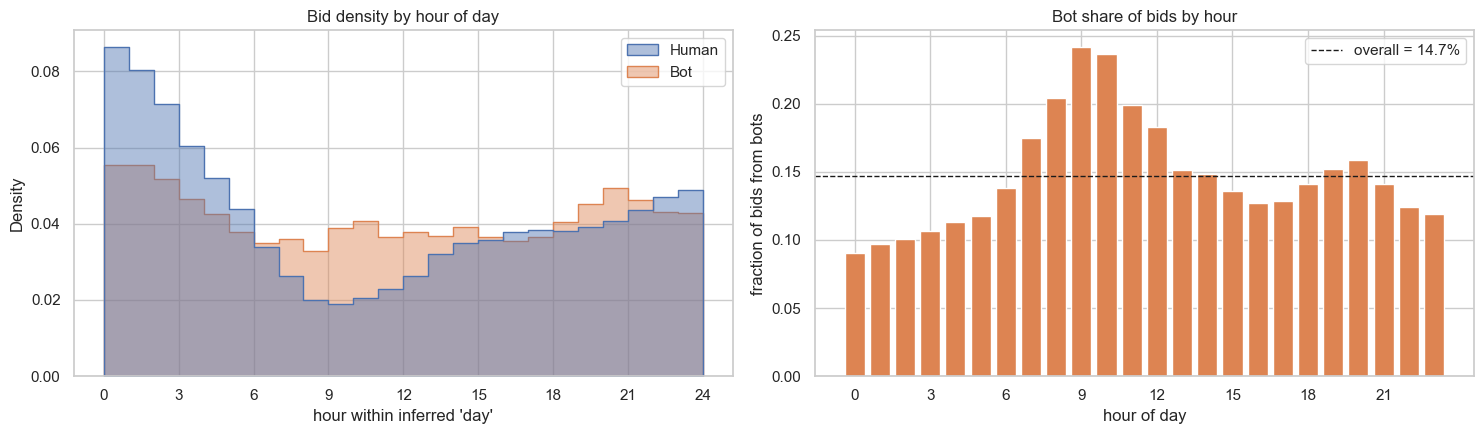

In [28]:
# Map each bid to hour-of-day using the inferred unit.
hours_lab = ((df_labeled["time"].to_numpy() - t_min) / unit_per_sec / 3600) % 24
out_lab = df_labeled["outcome"].to_numpy()
group_lab = np.where(out_lab == 1, "Bot", "Human")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.histplot(
    x=hours_lab,
    hue=group_lab,
    hue_order=["Human", "Bot"],
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.45,
    palette=PALETTE,
    ax=axes[0],
)
axes[0].set_xticks(range(0, 25, 3))
axes[0].set_xlabel("hour within inferred 'day'")
axes[0].set_title("Bid density by hour of day")

# Bot share of bids by hour: if bots don't sleep, their share should spike at night.
hod = pl.DataFrame({"hour": hours_lab, "is_bot": (out_lab == 1).astype(np.int8)})
by_hour = (
    hod.with_columns(pl.col("hour").cast(pl.Int32).alias("hour_bin"))
    .group_by("hour_bin")
    .agg(pl.col("is_bot").mean().alias("bot_frac"))
    .sort("hour_bin")
)
hour_idx = by_hour["hour_bin"].to_numpy()
bot_frac = by_hour["bot_frac"].to_numpy()
overall = float(bot_frac.mean())

axes[1].bar(hour_idx, bot_frac, color=PALETTE["Bot"])
axes[1].axhline(
    overall,
    color="k",
    linestyle="--",
    linewidth=1,
    label=f"overall = {overall:.1%}",
)
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_xlabel("hour of day")
axes[1].set_ylabel("fraction of bids from bots")
axes[1].set_title("Bot share of bids by hour")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations**

- Human hour-of-day density has a clear trough; bot density is much flatter.
- Right plot: **bot share of bids by hour** rises during the human nighttime trough.
- Confirms bots operate more uniformly across the 24-hour cycle.
- Features worth building: `hour_of_day` (24 bins) and coarser 3-hour slot bins (8 bins).

### 6.5 Q13: Simultaneous bidding across auctions

A bidder placing bids in two or more auctions at the *exact same* timestamp is doing something physically hard for a human. For each bidder, count the number of timestamps at which they have bids in $\geq 2$ distinct auctions, and compare the distribution across classes.

Fraction of bidders with >= 1 simultaneous bid event:
  Humans: 15.76%
  Bots  : 71.84%


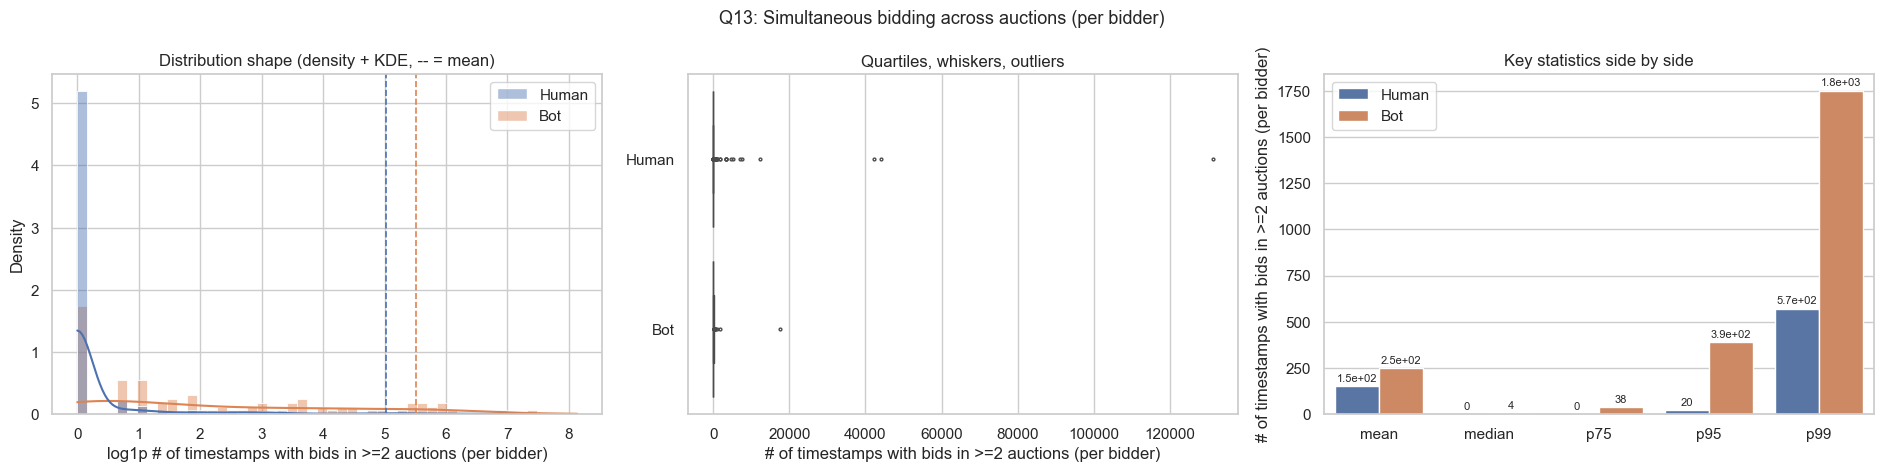

shape: (2, 11)
┌───────┬──────┬────────────┬─────────────┬───┬──────┬───────┬─────────┬──────────┐
│ group ┆ n    ┆ mean       ┆ std         ┆ … ┆ p75  ┆ p95   ┆ p99     ┆ max      │
│ ---   ┆ ---  ┆ ---        ┆ ---         ┆   ┆ ---  ┆ ---   ┆ ---     ┆ ---      │
│ str   ┆ i64  ┆ f64        ┆ f64         ┆   ┆ f64  ┆ f64   ┆ f64     ┆ f64      │
╞═══════╪══════╪════════════╪═════════════╪═══╪══════╪═══════╪═════════╪══════════╡
│ Human ┆ 1910 ┆ 151.331937 ┆ 3340.229964 ┆ … ┆ 0.0  ┆ 20.0  ┆ 570.84  ┆ 131379.0 │
│ Bot   ┆ 103  ┆ 247.747573 ┆ 1724.853717 ┆ … ┆ 38.5 ┆ 388.5 ┆ 1751.24 ┆ 17530.0  │
└───────┴──────┴────────────┴─────────────┴───┴──────┴───────┴─────────┴──────────┘


In [29]:
# Count, per bidder, the number of timestamps where they have bids
# in at least 2 distinct auctions at that exact time.
simul = (
    df_labeled.group_by(["bidder_id", "time"])
    .agg(pl.n_unique("auction").alias("n_auctions_same_ts"))
    .filter(pl.col("n_auctions_same_ts") > 1)
    .group_by("bidder_id")
    .agg(pl.len().alias("n_simultaneous"))
)

# Include bidders with zero simultaneous events.
all_bidders = (
    df_train.select("bidder_id", "outcome")
    .join(simul, on="bidder_id", how="left")
    .with_columns(pl.col("n_simultaneous").fill_null(0))
)

human_s = all_bidders.filter(pl.col("outcome") == 0)["n_simultaneous"].to_numpy()
bot_s = all_bidders.filter(pl.col("outcome") == 1)["n_simultaneous"].to_numpy()

print("Fraction of bidders with >= 1 simultaneous bid event:")
print(f"  Humans: {(human_s > 0).mean():.2%}")
print(f"  Bots  : {(bot_s > 0).mean():.2%}")

compare_distributions(
    human_s,
    bot_s,
    xlabel="# of timestamps with bids in >=2 auctions (per bidder)",
    title="Q13: Simultaneous bidding across auctions (per bidder)",
    log_x=True,
)

**Observations**

- Sharpest single signal in the notebook:
  - Bots with $\geq 1$ simultaneous event: **71.84%**
  - Humans with $\geq 1$ simultaneous event: **15.76%**
- A binary `has_simultaneous` flag alone is a strong weak learner.
- Raw count `n_simultaneous` is tail-heavy and noisy:
  - human max = 131,379 (large outlier dragging the mean)
  - bot max = 17,530
- For modeling: prefer the binary flag over the raw count; optionally include `log1p(n_simultaneous)` for tail information.

## 7. Bot rate by country and merchandise

Do particular countries or merchandise categories concentrate bots disproportionately? These category-level rates are natural candidate features (target encoding), with the usual leakage caveats.

### 7.1 Q14: Per-category bot rate (country and merchandise)

Do some countries or merchandise categories attract disproportionately many bots? We compute the fraction of distinct bidders active on each category who are labeled as bots. A category with a visibly elevated rate is a candidate for *target encoding* in modeling, with the caveat that target-encoded features leak labels if not computed fold-wise.

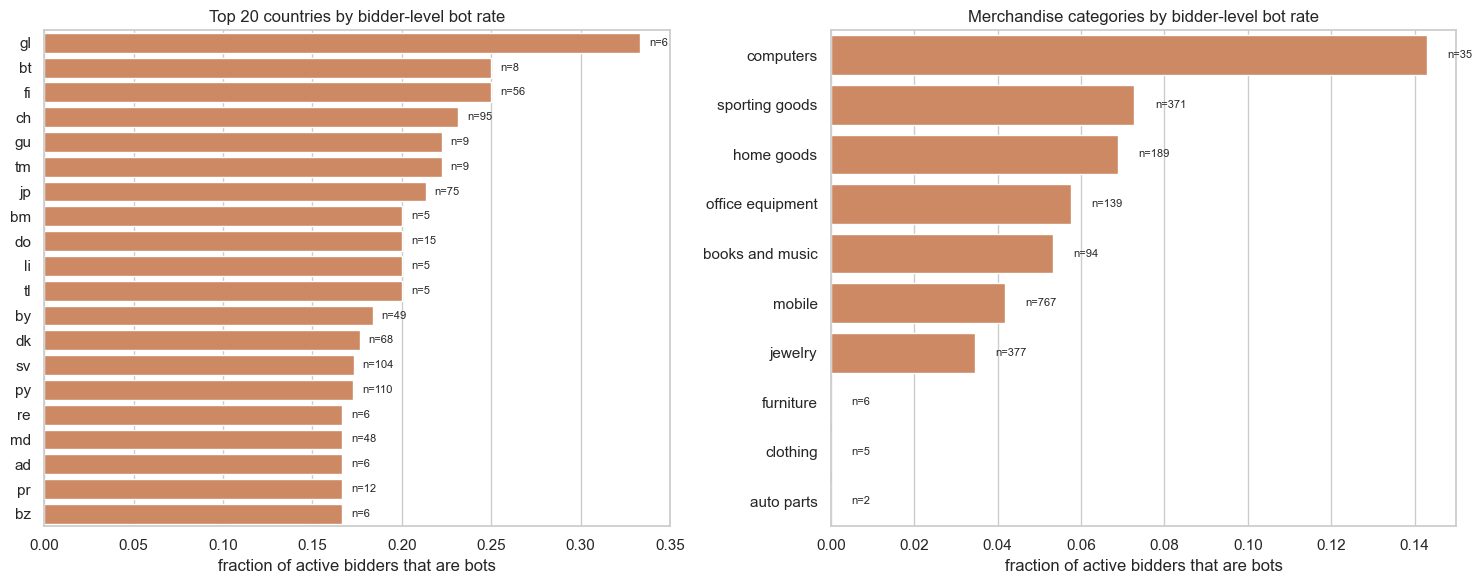

In [30]:
# For each level of a categorical, compute the fraction of distinct bidders
# (active on that level) who are bots. Only keep levels with enough bidders
# to make the rate meaningful.
def cat_bot_rate(cat_col, top_n=20, min_bidders=5):
    return (
        df_labeled.select("bidder_id", cat_col, "outcome")
        .unique()
        .group_by(cat_col)
        .agg(
            n_bidders=pl.n_unique("bidder_id"),
            bot_rate=pl.col("outcome").mean(),
        )
        .filter(pl.col("n_bidders") >= min_bidders)
        .sort("bot_rate", descending=True)
        .head(top_n)
    )


top_country = cat_bot_rate("country", top_n=20, min_bidders=5)
top_merch = cat_bot_rate("merchandise", top_n=20, min_bidders=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    x=top_country["bot_rate"].to_numpy(),
    y=top_country["country"].to_numpy(),
    color=PALETTE["Bot"],
    ax=axes[0],
)
axes[0].set_title("Top 20 countries by bidder-level bot rate")
axes[0].set_xlabel("fraction of active bidders that are bots")
for i, (rate, n) in enumerate(
    zip(top_country["bot_rate"].to_list(), top_country["n_bidders"].to_list())
):
    axes[0].text(rate + 0.005, i, f"n={n}", va="center", fontsize=8)

sns.barplot(
    x=top_merch["bot_rate"].to_numpy(),
    y=top_merch["merchandise"].to_numpy(),
    color=PALETTE["Bot"],
    ax=axes[1],
)
axes[1].set_title("Merchandise categories by bidder-level bot rate")
axes[1].set_xlabel("fraction of active bidders that are bots")
for i, (rate, n) in enumerate(
    zip(top_merch["bot_rate"].to_list(), top_merch["n_bidders"].to_list())
):
    axes[1].text(rate + 0.005, i, f"n={n}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

**Observations**

- Several country and merchandise categories exceed the 5.12% global bot baseline.
- Rates based on few bidders (low `n`) are unstable, so smooth before use (e.g. Bayesian shrinkage toward the global mean).
- Target-encoded category features are candidates, but they **leak labels** if not computed fold-wise.
- For a DL model, an embedding on the raw categorical is a leakage-free alternative.

## 8. Feature synthesis: correlations

Pulling every per-bidder signal into one matrix and checking redundancy and label association.

### 8.1 Q15: Correlation of bidder-level features

Now that we have a handful of candidate features, how redundant are they with each other, and which ones correlate most strongly with `outcome`? Log-transform the skewed quantities first so the correlations reflect monotone relationships.

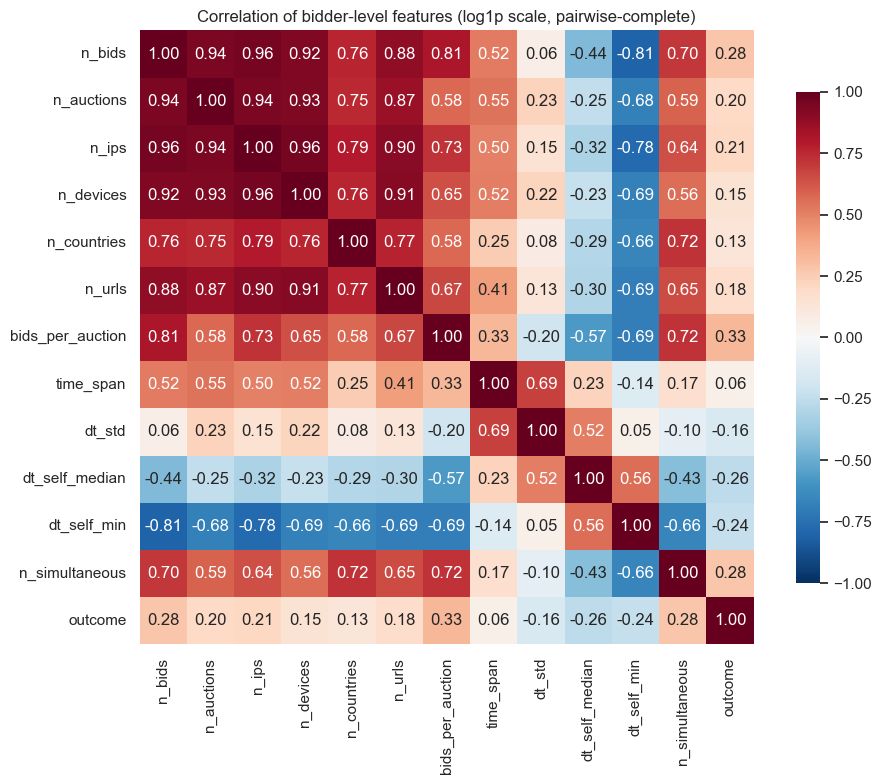

Features ranked by |correlation| with outcome:
  bids_per_auction     +0.3290
  n_simultaneous       +0.2795
  n_bids               +0.2786
  dt_self_median       -0.2596
  dt_self_min          -0.2363
  n_ips                +0.2055
  n_auctions           +0.2003
  n_urls               +0.1799
  dt_std               -0.1609
  n_devices            +0.1455
  n_countries          +0.1300
  time_span            +0.0619


In [31]:
# Build a compact per-bidder feature matrix for correlation analysis.
per_bidder = (
    df_labeled.group_by("bidder_id")
    .agg(
        n_bids=pl.len(),
        n_auctions=pl.n_unique("auction"),
        n_ips=pl.n_unique("ip"),
        n_devices=pl.n_unique("device"),
        n_countries=pl.n_unique("country"),
        n_urls=pl.n_unique("url"),
        bids_per_auction=pl.len() / pl.n_unique("auction"),
        time_span=(pl.max("time") - pl.min("time")),
    )
    .join(dt_std.select("bidder_id", "dt_std"), on="bidder_id", how="left")
    .join(
        time_diffs.group_by("bidder_id").agg(
            pl.median("dt").alias("dt_self_median"),
            pl.min("dt").alias("dt_self_min"),
        ),
        on="bidder_id",
        how="left",
    )
    .join(
        all_bidders.select("bidder_id", "n_simultaneous"),
        on="bidder_id",
        how="left",
    )
    .join(df_train.select("bidder_id", "outcome"), on="bidder_id", how="left")
    .drop_nulls(subset=["outcome"])
)

# Log-transform skewed features so correlations reflect monotone relationships.
log_cols = [
    "n_bids",
    "n_auctions",
    "n_ips",
    "n_devices",
    "n_urls",
    "bids_per_auction",
    "time_span",
    "dt_std",
    "dt_self_median",
    "dt_self_min",
    "n_simultaneous",
]
feat_df = per_bidder.drop("bidder_id").with_columns(
    [
        pl.col(c).cast(pl.Float64).log1p().alias(c)
        for c in log_cols
        if c in per_bidder.columns
    ]
)

# Pairwise-complete Pearson correlation: polars' .corr() propagates nulls
# listwise, which wipes out dt_std / dt_self_* (null for bidders with < 2 bids).
# Compute each pair on the rows where BOTH columns are non-null.
labels = feat_df.columns
data = feat_df.to_numpy().astype(np.float64)  # nulls become NaN
n_feat = data.shape[1]
corr_values = np.full((n_feat, n_feat), np.nan)
for i in range(n_feat):
    for j in range(n_feat):
        a, b = data[:, i], data[:, j]
        m = ~(np.isnan(a) | np.isnan(b))
        if m.sum() > 1:
            corr_values[i, j] = np.corrcoef(a[m], b[m])[0, 1]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_values,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation of bidder-level features (log1p scale, pairwise-complete)")
plt.tight_layout()
plt.show()

# Rank features by absolute correlation with outcome.
outcome_idx = labels.index("outcome")
corr_with_outcome = corr_values[outcome_idx]
ranking = sorted(
    [
        (labels[i], float(corr_with_outcome[i]))
        for i in range(len(labels))
        if labels[i] != "outcome"
    ],
    key=lambda kv: abs(kv[1]),
    reverse=True,
)
print("Features ranked by |correlation| with outcome:")
for name, val in ranking:
    print(f"  {name:<20s} {val:+.4f}")

**Observations**

- Features ranked by |corr(feature, outcome)|:

  | rank | feature | corr |
  | --- | --- | --- |
  | 1 | `bids_per_auction` | +0.33 |
  | 2 | `n_simultaneous` | +0.28 |
  | 3 | `n_bids` | +0.28 |
  | 4 | `dt_self_median` | -0.26 |
  | 5 | `dt_self_min` | -0.24 |
  | 6 | `n_ips` | +0.21 |
  | 7 | `n_auctions` | +0.20 |
  | 8 | `n_urls` | +0.18 |
  | 9 | `dt_std` | -0.16 |
  | 10 | `n_devices` | +0.15 |
  | 11 | `n_countries` | +0.13 |
  | 12 | `time_span` | +0.06 |

- No single feature exceeds $|r| = 0.33$, so no silver bullet. The model needs combinations.
- Signs match behavioral expectations:
  - count-style features: **positive** (bots have more)
  - own-bid time gaps: **negative** (bots are faster)
  - `dt_std`: **negative** (bots are more regular)
- Heatmap: `n_bids`, `n_auctions`, `n_ips`, `n_urls`, `n_devices` form a tightly correlated block, so these are redundant.
- `dt_self_median` and `dt_self_min` cluster together, also redundant.
- For tabular: collapse the count block to ratios or entropies before training.
- For DL: keep them all, let the network learn interactions.

## 9. Takeaways for feature engineering

Things this EDA surfaced that should flow into the feature design:

1. **Time unit recovered.** We now have `unit_per_sec`, so we can construct `hour_of_day`, `day_of_campaign`, and 3-hour time-of-day slots as model features.
2. **Three disjoint chunks of ~3 active days.** `day_of_campaign` is a small finite categorical (~9 levels), not a continuous axis.
3. **Reaction to *other* bidders** separates the two classes more sharply than reaction to the bidder's own previous bid. Worth adding `dt_others_median` and `dt_others_min`.
4. **Simultaneous bidding is near-binary.** Any bidder with $\geq 1$ simultaneous event is heavily bot-biased. A `has_simultaneous` flag is cheap and strong.
5. **Diversity ratios beat raw counts.** Bots show unusually high `unique_ips / total_bids` and `unique_devices / total_bids`. Use ratios and entropy-style summaries rather than just counts.
6. **Per-category bot rate.** `country` and `merchandise` concentrate bots unevenly. This is high-lift but leakage-prone: if used as a feature (target encoding), it must be computed **fold-wise**.
7. **Correlation redundancy.** The raw count features move together. For a DL model, normalize on log-scale and let the network learn combinations; for a tabular baseline, pick a pruned set.
8. **Class imbalance is severe.** Plan for weighted loss, AUC-tracked validation, and repeated CV since a single split will be noisy.